In [185]:
import pandas as pd 
import numpy as np

In [186]:
df = pd.read_csv("../Data/Housing_2.csv")
housing_data = df[["area","price", "bedrooms","bathrooms","prefarea"]]
housing_data


,area,price,bedrooms,bathrooms,prefarea
0,7420,13300000,4,2,1
1,8960,12250000,4,4,0
2,9960,12250000,3,2,1
3,7500,12215000,4,2,1
4,7420,11410000,4,1,0
...,...,...,...,...,...
540,3000,1820000,2,1,0
541,2400,1767150,3,1,0
542,3620,1750000,2,1,0
543,2910,1750000,3,1,0


<Axes: xlabel='area', ylabel='price'>

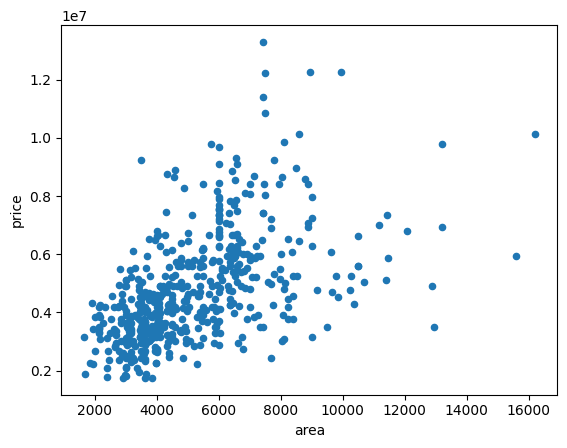

In [187]:
housing_data.plot.scatter(x="area", y ="price")

<Axes: xlabel='area', ylabel='bedrooms'>

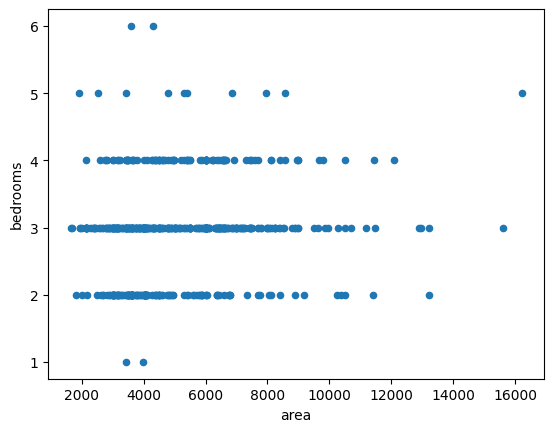

In [188]:
housing_data.plot.scatter(x="area", y ="bedrooms")

<Axes: xlabel='area', ylabel='bathrooms'>

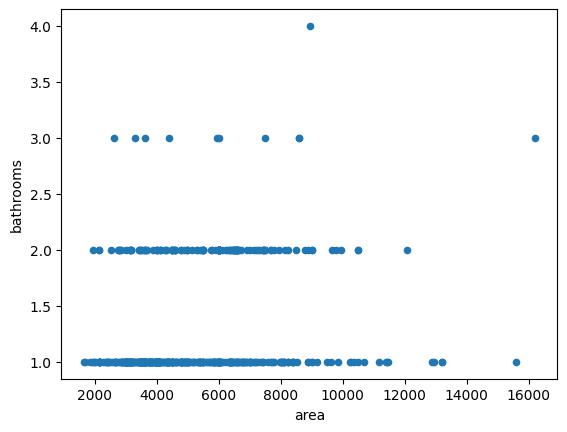

In [189]:
housing_data.plot.scatter(x="area", y ="bathrooms")

<Axes: xlabel='area', ylabel='prefarea'>

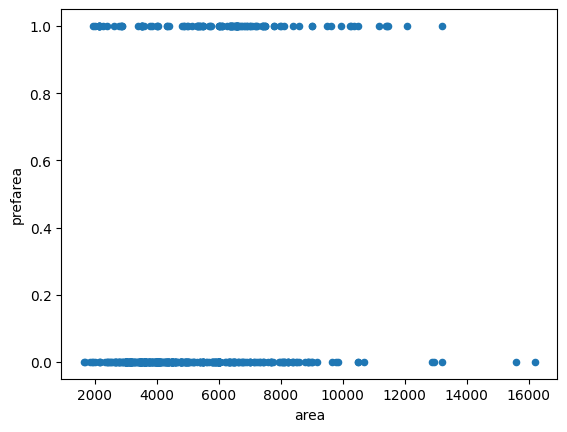

In [190]:
housing_data.plot.scatter(x="area", y ="prefarea")

In [191]:
housing_data["price"] = housing_data["price"]/1000000

In [192]:
housing_data.head(5)

,area,price,bedrooms,bathrooms,prefarea
0,7420,13.300,4,2,1
1,8960,12.250,4,4,0
2,9960,12.250,3,2,1
3,7500,12.215,4,2,1
4,7420,11.410,4,1,0


<Axes: xlabel='area', ylabel='price'>

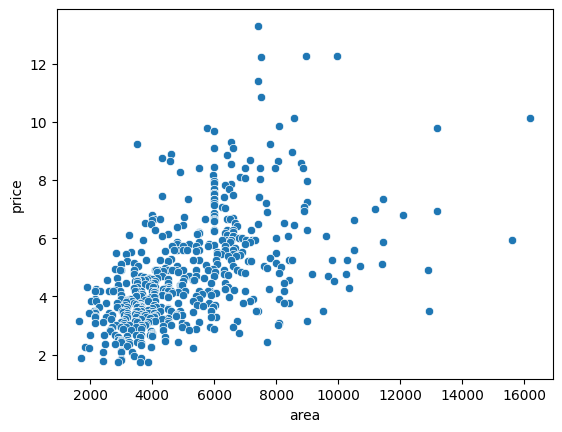

In [193]:
import seaborn as sns
sns.scatterplot(housing_data,x ="area", y = "price")

In [194]:
np.random.seed(32)
housing_data["split"]= np.random.choice(["train","test"], size=len(housing_data),p=[0.8,0.2])

In [195]:
housing_data.head(10)

,area,price,bedrooms,bathrooms,prefarea,split
0,7420,13.300,4,2,1,test
1,8960,12.250,4,4,0,train
2,9960,12.250,3,2,1,train
3,7500,12.215,4,2,1,test
4,7420,11.410,4,1,0,train
5,7500,10.850,3,3,1,test
6,8580,10.150,4,3,1,train
7,16200,10.150,5,3,0,test
8,8100,9.870,4,1,1,train
9,5750,9.800,3,2,1,train


<Axes: xlabel='area', ylabel='price'>

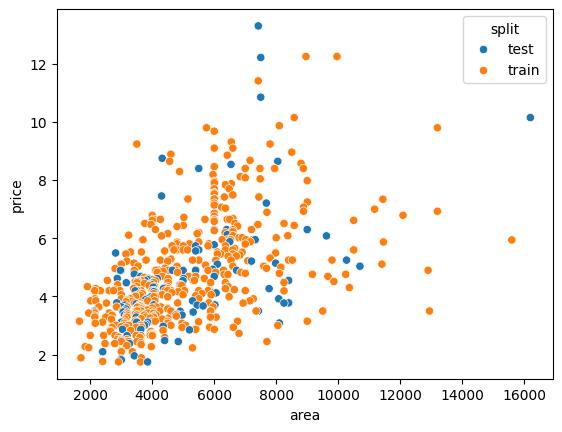

In [196]:
sns.scatterplot(housing_data,x ="area", y = "price", hue ="split")

In [197]:
train_data = housing_data[housing_data["split"]=="train"].drop("split", axis = 1)

train_data

,area,price,bedrooms,bathrooms,prefarea
1,8960,12.25000,4,4,0
2,9960,12.25000,3,2,1
4,7420,11.41000,4,1,0
6,8580,10.15000,4,3,1
8,8100,9.87000,4,1,1
...,...,...,...,...,...
537,1700,1.89000,3,1,0
538,3649,1.89000,2,1,0
541,2400,1.76715,3,1,0
542,3620,1.75000,2,1,0


In [198]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [199]:
lr_one = LinearRegression()

In [200]:
X_train = train_data[["area", "bedrooms","bathrooms","prefarea"]]
y_train = train_data["price"]


In [201]:
lr_one.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Here we start the ML course

In [202]:
slope = lr_one.coef_[0]
print(f"Slope :{slope}")

Slope :0.0003499577030418876


In [203]:
slope = lr_one.coef_[1]
print(f"Slope :{slope}")

Slope :0.42031946657512


In [204]:
slope = lr_one.coef_[2]
print(f"Slope :{slope}")

Slope :1.260040047856591


In [205]:
slope = lr_one.coef_[3]
print(f"Slope :{slope}")

Slope :0.7581019556498916


In [206]:
intercept = lr_one.intercept_
print(f"intercept : {intercept}")

intercept : -0.06287396397425837


In [207]:
y_pred = lr_one.predict(X_train)

In [208]:
train_data.head()

,area,price,bedrooms,bathrooms,prefarea
1,8960,12.25,4,4,0
2,9960,12.25,3,2,1
4,7420,11.41,4,1,0
6,8580,10.15,4,3,1
8,8100,9.87,4,1,1


In [209]:
Y_MANUAL = lr_one.coef_[0] * 8960 + lr_one.coef_[1] * 4 + lr_one.coef_[2] * 4 + lr_one.intercept_ 

In [210]:
Y_MANUAL

np.float64(9.794185113007899)

In [211]:
np.sum(np.abs(y_pred-y_train))/len(y_pred)

np.float64(0.9688297058378003)

In [212]:
np.sqrt(mean_squared_error(y_pred,y_train))

np.float64(1.2833991067491215)

In [213]:
test_data = housing_data[housing_data["split"]=="test"].drop("split", axis = 1)
X_test = test_data[["area", "bedrooms","bathrooms","prefarea"]]
y_test = test_data["price"]

In [214]:
y_test_pred = lr_one.predict(X_test)

In [215]:
np.sqrt(mean_squared_error(y_test_pred,y_test))

np.float64(1.3151090086176256)

<Axes: xlabel='price'>

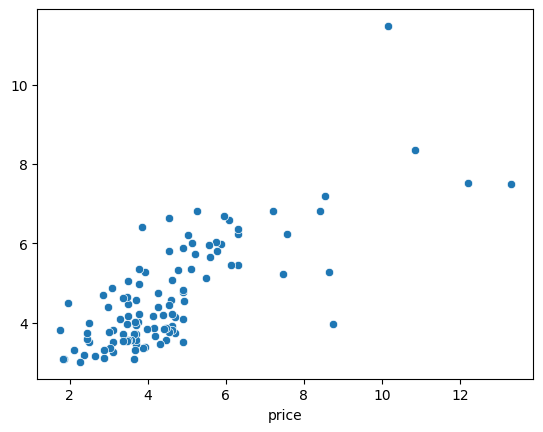

In [216]:
sns.scatterplot(x=y_test,y=y_test_pred)